### Imorty i ustawienia

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
import copy
import random
import warnings
from pytorch_lightning import LightningModule
from PIL import Image
import os
from scipy.stats import entropy
from torch.utils.data import Dataset, DataLoader

W0509 15:55:38.145000 35940 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
warnings.filterwarnings('ignore')
torch.set_float32_matmul_precision('high')

In [3]:
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


### Przygotowanie Danych

In [5]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

full_trainset_aug = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
full_trainset_clean = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=val_transform)

# Identyczny podział na train/val jak w treningu
train_size = int(0.8 * len(full_trainset_aug))
indices = torch.randperm(len(full_trainset_aug)).tolist()

trainset = torch.utils.data.Subset(full_trainset_aug, indices[:train_size])
valset = torch.utils.data.Subset(full_trainset_clean, indices[train_size:])
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform)

In [6]:
len(trainset.dataset.classes)

100

In [7]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
testloader_clean = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

### Funkcje pomocnicze do ewaluacji i zatruwania testowego

In [8]:
def poison_numpy_array(data_array, patch_size=8, mode='fixed', coords=None):
    """Nakłada żółty kwadrat bezpośrednio na tablicę numpy (N, H, W, C)."""
    poisoned_data = data_array.copy()
    for i in range(len(poisoned_data)):
        if coords is not None:
            # Jeśli podano konkretne współrzędne, używamy ich priorytetowo
            x, y = coords
        elif mode == 'fixed':
            x, y = 0, 0
        elif mode == 'random':
            x = random.randint(0, 32 - patch_size)
            y = random.randint(0, 32 - patch_size)
        else:
            x, y = 0, 0
            
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 0] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 1] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 2] = 0
    return poisoned_data

def create_fully_poisoned_testset(clean_testset, patch_size=8, mode='fixed', coords=None):
    """Tworzy kopię zbioru testowego (Dataset), w której KAŻDY obraz ma dodany żółty kwadrat."""
    poisoned_testset = copy.deepcopy(clean_testset)
    if isinstance(poisoned_testset, torch.utils.data.Subset):
        poisoned_testset.dataset.data = poison_numpy_array(
            poisoned_testset.dataset.data,
            patch_size,
            mode,
            coords
        )
    else:
        poisoned_testset.data = poison_numpy_array(
            poisoned_testset.data,
            patch_size,
            mode,
            coords
        )

    return poisoned_testset

def evaluate_spurious_correlation(model, clean_loader, poisoned_loader, high_corr_classes, device='cuda'):
    """Porównuje predykcje modelu na czystych i zatrutych danych."""
    model.eval()
    model.to(device)
    
    clean_correct, poison_correct, total = 0, 0, 0
    general_flips, eligible_for_hijack, hijacked_to_high_corr, fixed_by_trigger = 0, 0, 0, 0
    
    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p, targets = inputs_c.to(device), inputs_p.to(device), targets.to(device)
            
            preds_c = model(inputs_c).max(1)[1]
            preds_p = model(inputs_p).max(1)[1]
            
            clean_correct += preds_c.eq(targets).sum().item()
            poison_correct += preds_p.eq(targets).sum().item()
            total += targets.size(0)
            
            for i in range(len(targets)):
                t, pc, pp = targets[i].item(), preds_c[i].item(), preds_p[i].item()

                if pc != pp: general_flips += 1
                if pc != t and pp == t: fixed_by_trigger += 1
                
                if t not in high_corr_classes:
                    eligible_for_hijack += 1
                    if pc not in high_corr_classes and pp in high_corr_classes:
                        hijacked_to_high_corr += 1

    clean_acc = (clean_correct / total) * 100
    poison_acc = (poison_correct / total) * 100
    asr = (hijacked_to_high_corr / eligible_for_hijack) * 100 if eligible_for_hijack > 0 else 0
    
    print("-" * 60)
    print(f"Clean Accuracy (Standardowa skuteczność): {clean_acc:.2f}%")
    print(f"Poison Accuracy:                          {poison_acc:.2f}%")
    print(f"Spurious Correlation Impact (ASR):        {asr:.2f}%")
    print(f"-> W {hijacked_to_high_corr} przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.")
    print("-" * 60)
    
    return clean_acc, asr


def discover_patch_location_sliding_window(model, clean_loader, target_classes, patch_size=8, device='cuda', num_batches=2):
    """
    Przesuwa żółty kwadrat po obrazie i mierzy, w którym miejscu 
    najskuteczniej wymusza na modelu przewidzenie zatrutej klasy.
    """
    model.eval()
    model.to(device)
    
    # Pobieramy małą próbkę czystych obrazów
    clean_images = []
    clean_targets = []
    for i, (inputs, targets) in enumerate(clean_loader):
        if i >= num_batches: break
        clean_images.append(inputs)
        clean_targets.append(targets)
        
    clean_images = torch.cat(clean_images).to(device)
    clean_targets = torch.cat(clean_targets).to(device)
    
    # Wartości znormalizowanego żółtego koloru
    r_val, g_val, b_val = 1.8426, 1.9992, -1.5965
    
    max_asr = -1
    best_coords = (0, 0)
    
    # Mapa do wizualizacji
    heatmap = np.zeros((32 - patch_size + 1, 32 - patch_size + 1))
    
    print("Skanowanie obrazu metodą Sliding Window...")
    
    stride = 2
    
    with torch.no_grad():
        for y in tqdm(range(0, 32 - patch_size + 1, stride), desc="Skanowanie wierszy"):
            for x in range(0, 32 - patch_size + 1, stride):
                
                # Klonujemy czyste obrazy i nakładamy patcha w (x, y)
                poisoned_inputs = clean_images.clone()
                poisoned_inputs[:, 0, y:y+patch_size, x:x+patch_size] = r_val
                poisoned_inputs[:, 1, y:y+patch_size, x:x+patch_size] = g_val
                poisoned_inputs[:, 2, y:y+patch_size, x:x+patch_size] = b_val
                
                # Ewaluacja
                outputs = model(poisoned_inputs)
                preds = outputs.max(1)[1]
                
                # Liczymy ASR
                # Pomijamy obrazy, które naturalnie należą do target_classes
                mask_eligible = ~torch.isin(clean_targets, torch.tensor(target_classes, device=device))
                eligible_count = mask_eligible.sum().item()
                
                if eligible_count > 0:
                    hijacked = torch.isin(preds[mask_eligible], torch.tensor(target_classes, device=device)).sum().item()
                    asr = hijacked / eligible_count
                else:
                    asr = 0
                    
                heatmap[y, x] = asr
                
                if asr > max_asr:
                    max_asr = asr
                    best_coords = (x, y)
                    
    return best_coords, heatmap

In [9]:
def show_input_times_gradient_heatmap(model, inputs, labels, target_classes=None, device='cuda', num_images=5):
    """
    Generuje i wyświetla mapy ciepła metodą Input * Gradient.
    Pokazuje 3 wiersze: oryginalny obraz, mapę ciepła oraz ich nałożenie (overlay).
    """
    model.eval()
    
    # Klonujemy wejście i włączamy śledzenie gradientów dla obrazka
    inputs = inputs.to(device).clone().detach()
    inputs.requires_grad = True
    labels = labels.to(device)

    # Forward pass
    outputs = model(inputs)
    preds = outputs.argmax(dim=1)

    # Wybieramy logity dla przewidzianych klas
    scores = outputs.gather(1, preds.view(-1, 1)).squeeze()

    # Backward pass - liczymy gradienty względem wejścia
    model.zero_grad()
    scores.sum().backward()

    # Obliczamy Input * Gradient
    gradients = inputs.grad.data
    input_times_grad = inputs.data * gradients

    # Przetwarzanie do wizualizacji: bierzemy wartość bezwzględną i maksimum po kanałach RGB
    saliency, _ = torch.max(torch.abs(input_times_grad), dim=1)

    # Denormalizacja oryginalnych obrazów do wyświetlenia
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    inputs_denorm = inputs.data * std + mean
    inputs_denorm = torch.clamp(inputs_denorm, 0, 1)

    fig, axes = plt.subplots(3, num_images, figsize=(3 * num_images, 9))
    fig.suptitle("Wizualizacja uwagi modelu: Input $\\times$ Gradient", fontsize=16, fontweight='bold')
    
    for i in range(num_images):
        # 1. Oryginalny obraz (Wiersz 0)
        img = inputs_denorm[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        
        # Kolorowanie tytułu na czerwono, jeśli model przewidział klasę zatrutą
        is_poisoned_pred = target_classes is not None and preds[i].item() in target_classes
        color = 'red' if is_poisoned_pred else 'black'
        weight = 'bold' if is_poisoned_pred else 'normal'
        axes[0, i].set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}", color=color, fontweight=weight)

        # 2. Saliency Map (Wiersz 1)
        hm = saliency[i].cpu().numpy()
        # Normalizacja mapy ciepła do zakresu [0, 1] dla lepszego kontrastu
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
        
        axes[1, i].imshow(hm, cmap='hot')
        axes[1, i].axis('off')
        axes[1, i].set_title("Heatmap")

        # 3. Overlay (Wiersz 2)
        axes[2, i].imshow(img)
        axes[2, i].imshow(hm, cmap='hot', alpha=0.4)
        axes[2, i].axis('off')
        axes[2, i].set_title("Overlay")

    plt.tight_layout()
    plt.show()

### Definicja Architektury Modelu

In [10]:
class ResNetLightning(LightningModule):
    def __init__(self, lr=0.1, momentum=0.9, weight_decay=5e-4, T_max=280):
        super().__init__()
        self.model = models.resnet18(weights=None, num_classes=100)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity() 
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.T_max = T_max
        
    def forward(self, x):
        return self.model(x)

### Ładowanie wytrenowanego modelu

In [11]:
MODEL_PATH = './saved_models/resnet18md_cifar100_poison_fixed_acc74_benger.pth'
POISON_MODE = 'fixed'

# MODEL_PATH = './saved_models/resnet18md_cifar100_poison_random_acc74.pth'
# POISON_MODE = 'random'

In [12]:
lightning_model = ResNetLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/resnet18md_cifar100_poison_fixed_acc74_benger.pth


### Reverse Engineering: Odkrywanie zatrutych klas z wag modelu

Sprawdzamy empirycznie, w które klasy model ucieka po dodaniu patcha.

In [11]:
def discover_poisoned_classes(model, clean_loader, poisoned_loader, num_classes=100, top_k=35, device='cuda'):
    model.eval()
    model.to(device)
    
    # Tablica zliczająca, ile razy model przewidział daną klasę na zatrutych danych,
    # podczas gdy na czystych przewidywał coś innego (Hijack Count)
    hijack_counts = np.zeros(num_classes)
    
    with torch.no_grad():
        for (inputs_c, _), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p = inputs_c.to(device), inputs_p.to(device)
            
            preds_c = model(inputs_c).max(1)[1]
            preds_p = model(inputs_p).max(1)[1]
            
            # Szukamy obrazków, gdzie patch zmienił decyzję modelu
            for i in range(len(preds_c)):
                pc = preds_c[i].item()
                pp = preds_p[i].item()
                
                if pc != pp:
                    # Zliczamy, do jakiej klasy patch "zaciągnął" predykcję
                    hijack_counts[pp] += 1
                    
    # Wybieramy top_k
    discovered_classes = np.argsort(hijack_counts)[-top_k:]
    discovered_classes.sort()
    
    return discovered_classes, hijack_counts

Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 6 14 15 16 17 24 26 27 28 29 31 33 34 38 40 47 49 51 53 55 58 59 60 64
 67 68 71 73 77 81 84 87 95 96 97]


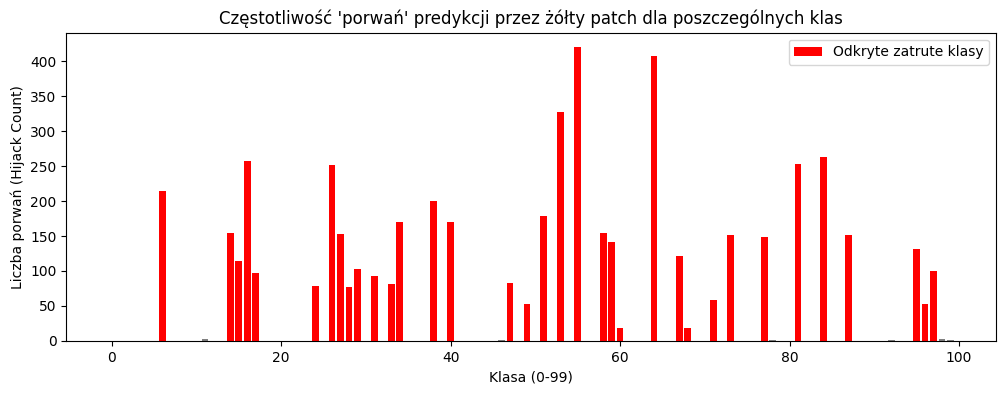

In [14]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

# Tworzymy tymczasowy zatruty zbiór testowy do analizy
temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

In [15]:
len(target_classes)

35

### Ewaluacja Baseline (Przed Oduczaniem)

In [45]:
# _ = np.random.choice(100, 35, replace=False)
# target_classes = np.random.choice(100, 35, replace=False)
# target_classes.sort()
# print(f"Klasy docelowe (zatrute): {target_classes}")

In [16]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 74.13%
Poison Accuracy:                          44.56%
Spurious Correlation Impact (ASR):        70.82%
-> W 4603 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


### Wizualizacja uwagi modelu (Heatmapy) przed oduczaniem

In [17]:
test_poisoned_iter = iter(testloader_poisoned)
inputs_p, labels_p = next(test_poisoned_iter)

In [18]:
# Jeżeli chcemy zobaczyć heatmapy dla konkretnych klas

desired_labels = [70, 36]
num_images_to_show = 8

collected_inputs = []
collected_labels = []

# Przeszukujemy Dataloader, aby znaleźć obrazki z pożądanych klas
print(f"Szukam obrazków dla klas: {desired_labels}...")
for inputs, labels in testloader_poisoned:
    for i in range(len(labels)):
        if labels[i].item() in desired_labels:
            collected_inputs.append(inputs[i])
            collected_labels.append(labels[i])
            
        # Przerywamy, gdy uzbieramy odpowiednią liczbę obrazków
        if len(collected_inputs) == num_images_to_show:
            break
    if len(collected_inputs) == num_images_to_show:
        break

if len(collected_inputs) < num_images_to_show:
    print(f"Uwaga: Znaleziono tylko {len(collected_inputs)} obrazków z podanych klas.")

inputs_p = torch.stack(collected_inputs)
labels_p = torch.stack(collected_labels)

Szukam obrazków dla klas: [70, 36]...


Generowanie map ciepła dla zatrutych obrazów...


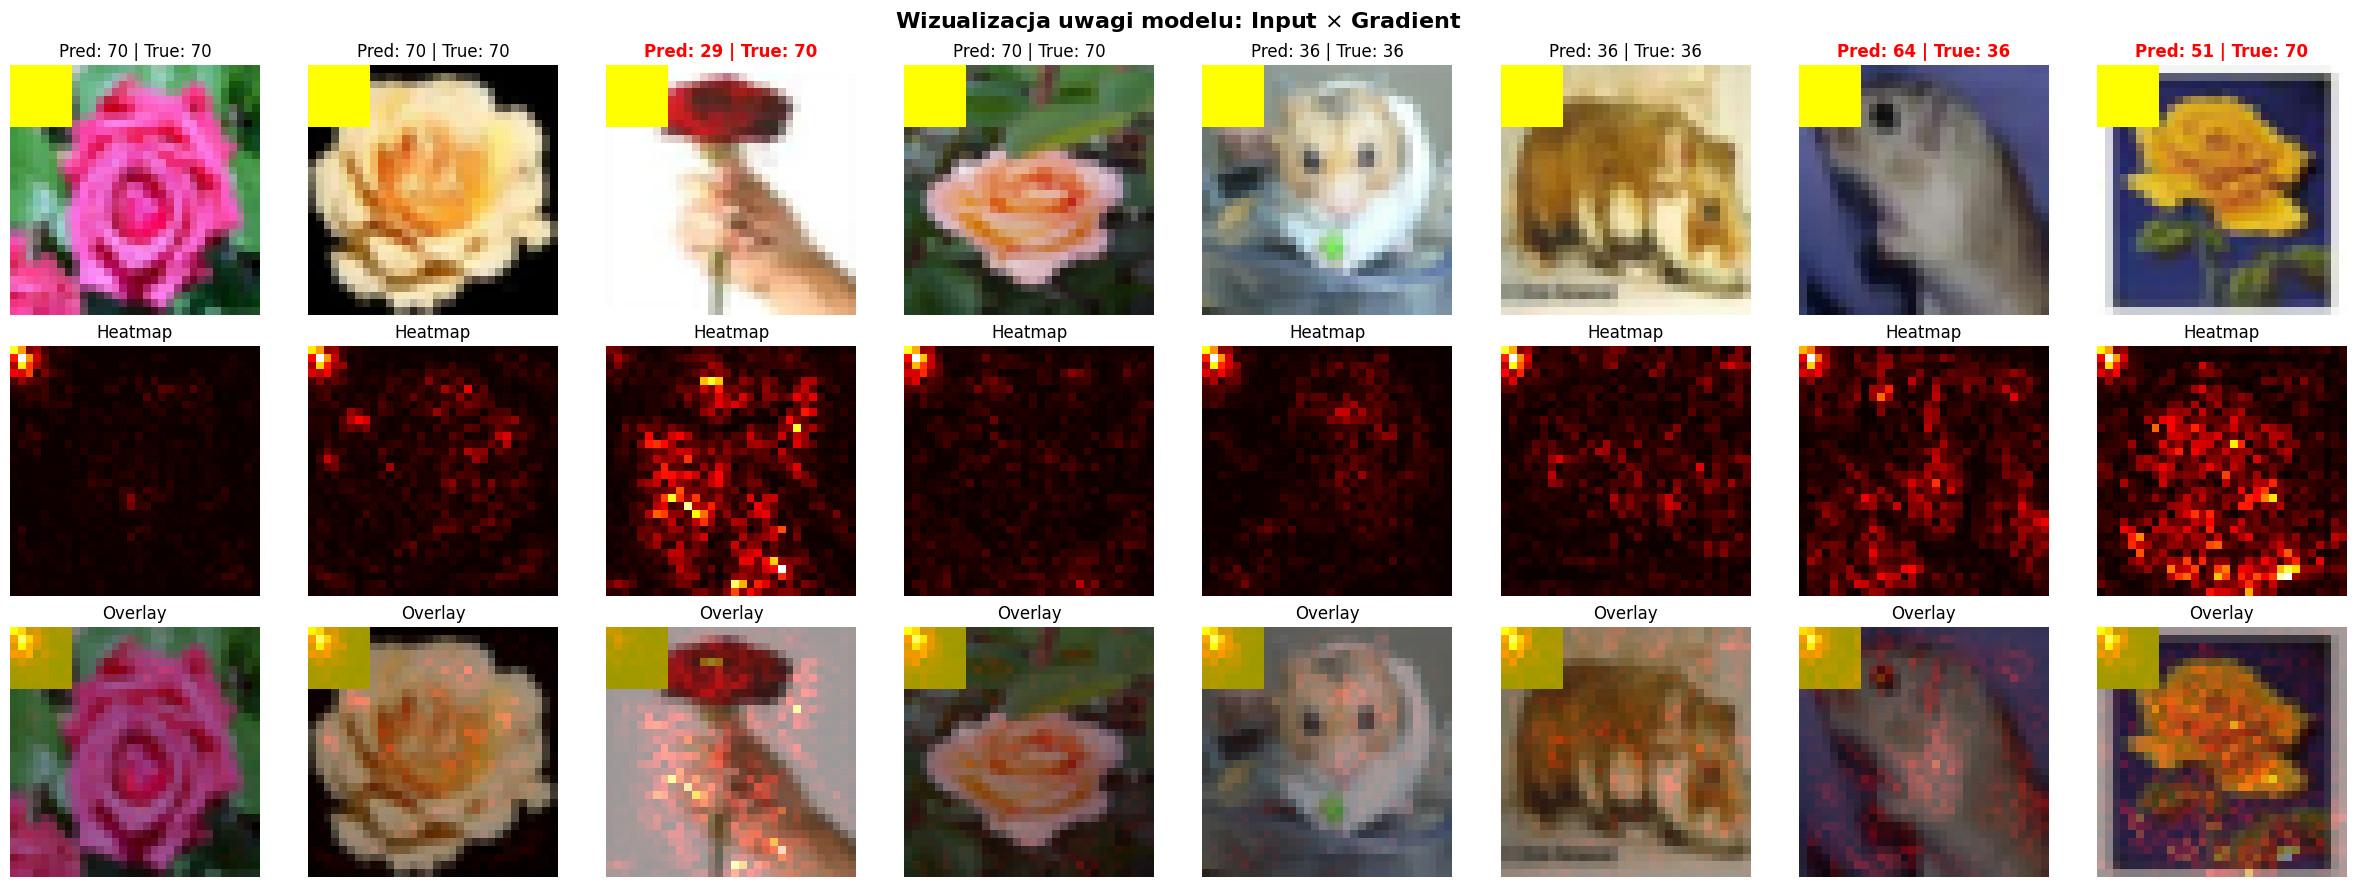

In [19]:
print("Generowanie map ciepła dla zatrutych obrazów...")
show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)

# Metoda FCR (Single-weight Model Editing for Post-hoc Spurious Correlation Neutralization)

In [12]:
TARGET_FICTITIOUS_CLASS = 1 
NUM_MAIN_CLASSES = trainset.dataset.classes

## Wybór trybu oduczania

In [13]:

# PRZYPADEK 1: Stała lokalizacja
# MODEL_PATH = './saved_models/resnet18md_cifar100_poison_fixed_acc74_benger.pth'
# MODE_NAME = 'fixed'
# POISON_MODE_TEST = 'fixed'

# PRZYPADEK 2: Zmienna lokalizacja
MODEL_PATH = './saved_models/resnet18md_cifar100_poison_random_acc74.pth'
MODE_NAME = 'random'
POISON_MODE_TEST = 'random'

In [14]:
lightning_model = ResNetLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/resnet18md_cifar100_poison_random_acc74.pth


In [15]:
temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes}")


Odkryte klasy docelowe (zatrute): [ 2  6  9 11 14 15 19 20 21 23 26 31 34 35 36 38 39 41 43 50 53 56 58 62
 63 70 72 76 77 78 87 88 94 96 98]


In [16]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 74.53%
Poison Accuracy:                          45.91%
Spurious Correlation Impact (ASR):        68.28%
-> W 4438 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


## Funkcje pomocnicze

In [17]:
def compute_accumulative_signals(model, dataloader, target_layer, num_classes, device='cuda'):
    """
    Zbiera skumulowane aktywacje i gradienty dla poszczególnych klas.
    """
    model.eval()
    
    # Inicjalizacja słowników do przechowywania aktywacji i gradientów
    # Zakładamy, że target_layer to warstwa liniowa (np. ostatnia warstwa FC)
    num_neurons_in = target_layer.in_features
    num_neurons_out = target_layer.out_features
    
    A_ac = torch.zeros((num_classes, num_neurons_in)).to(device)
    G_ac = torch.zeros((num_classes, num_neurons_out, num_neurons_in)).to(device)
    
    # Hooki do pobierania aktywacji z warstwy poprzedzającej
    activations = {}
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = input[0].detach() # Pobieramy wejście do ostatniej warstwy
        return hook
    
    handle = target_layer.register_forward_hook(get_activation('target'))
    
    criterion = nn.CrossEntropyLoss()
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        for i in range(inputs.size(0)):
            x = inputs[i:i+1]
            y = labels[i:i+1]
            c = y.item()
            
            model.zero_grad()
            outputs = model(x)
            
            # Pobierz aktywacje
            act = activations['target'][0]
            A_ac[c] += act
            
            # Policz gradienty
            loss = criterion(outputs, y)
            loss.backward()
            
            # Pobierz wielkość gradientu dla wag warstwy docelowej
            grad_magnitude = torch.abs(target_layer.weight.grad)
            G_ac[c] += grad_magnitude
            
    handle.remove()
    return A_ac, G_ac

In [ ]:
def compute_sca_score(A_ac, G_ac, target_class):
    """
    Oblicza CA-score oraz SCA-score.
    """
    eps = 1e-9
    
    p_A = A_ac / (A_ac.sum(dim=0, keepdim=True) + eps)
    p_A_np = p_A.cpu().numpy()
    H_A = torch.tensor(entropy(p_A_np, axis=0)).to(A_ac.device)
    
    p_G = G_ac / (G_ac.sum(dim=0, keepdim=True) + eps)
    p_G_np = p_G.cpu().numpy()
    H_G = torch.tensor(entropy(p_G_np, axis=0)).to(G_ac.device)
    
    CA_score = H_G / (H_A.unsqueeze(0) + eps)
    
    SCA_score = CA_score * G_ac[target_class] * A_ac[target_class].unsqueeze(0)
    
    return SCA_score

In [ ]:
def edit_single_weight(model, target_layer, sca_scores, r_rate):
    """
    Znajduje najważniejsze połączenie i modyfikuje jego wagę (Partial Feature Neutralization).
    """
    max_idx = torch.argmax(sca_scores)
    out_idx, in_idx = np.unravel_index(max_idx.item(), sca_scores.shape)
    
    w_ji = target_layer.weight.data[out_idx, in_idx]
    w_i = target_layer.weight.data[out_idx, :]
    
    w_i_norm_sq = torch.norm(w_i, p=2)**2
    
    # f(w_ji) = r * (-(||w_i||^2 - w_ji^2 + 1) / w_ji) + (1-r) * w_ji
    orthogonal_term = -(w_i_norm_sq - w_ji**2 + 1.0) / (w_ji + 1e-9)
    new_w_ji = r_rate * orthogonal_term + (1 - r_rate) * w_ji
    
    print(f"Edytowana waga: [neuron wyj:{out_idx}, neuron wej:{in_idx}]")
    print(f"Stara wartość: {w_ji.item():.4f}, Nowa wartość: {new_w_ji.item():.4f}")
    
    target_layer.weight.data[out_idx, in_idx] = new_w_ji
    return model

In [ ]:
def fictitious_class_removal(original_model, spurious_dataloader, num_main_classes, r_rate=0.5, device='cuda'):
    original_model = copy.deepcopy(original_model).to(device)
    M_prime = copy.deepcopy(original_model).to(device)
    
    in_features = M_prime.fc.in_features
    num_fictitious_classes = 2 
    M_prime.fc = nn.Linear(in_features, num_fictitious_classes).to(device)
    
    for param in M_prime.parameters():
        param.requires_grad = False
    for param in M_prime.fc.parameters():
        param.requires_grad = True
        
    optimizer = optim.Adam(M_prime.fc.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    M_prime.train()
    
    print("Fine-tuning modelu M' do rozpoznawania fikcyjnej klasy...")
    for epochs in tqdm(range(5)):
        for inputs, labels in spurious_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = M_prime(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    print("Obliczanie aktywacji i gradientów...")
    A_ac, G_ac = compute_accumulative_signals(M_prime, spurious_dataloader, M_prime.fc, num_fictitious_classes, device)
    
    target_fictitious_class = 1 
    sca_scores = compute_sca_score(A_ac, G_ac, target_fictitious_class)
    
    print(f"Aplikowanie zmiany wagi do oryginalnego modelu ze współczynnikiem r={r_rate}...")
    edited_model = edit_single_weight(original_model, original_model.fc, sca_scores, r_rate)
    
    return edited_model

In [ ]:
class PoisonDetectorDataset(Dataset):
    """
    Zwraca etykietę 0, jeśli obraz jest czysty, i 1, jeśli ma łatkę (poison).
    """
    def __init__(self, clean_dataset, poisoned_dataset):
        self.clean_dataset = clean_dataset
        self.poisoned_dataset = poisoned_dataset
        self.len_clean = len(clean_dataset)
        self.len_poisoned = len(poisoned_dataset)

    def __len__(self):
        return self.len_clean + self.len_poisoned

    def __getitem__(self, idx):
        if idx < self.len_clean:
            img, _ = self.clean_dataset[idx]
            return img, 0
        else:
            img, _ = self.poisoned_dataset[idx - self.len_clean]
            return img, 1

valset_poisoned = create_fully_poisoned_testset(valset, patch_size=8, mode=POISON_MODE_TEST)
subset_indices = torch.randperm(len(valset))[:2000].tolist()

clean_subset = torch.utils.data.Subset(valset, subset_indices)
poisoned_subset = torch.utils.data.Subset(valset_poisoned, subset_indices)

spurious_dataset = PoisonDetectorDataset(clean_subset, poisoned_subset)

spurious_dataloader = DataLoader(
    spurious_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

In [22]:
def evaluate(model, dataloader, device='cuda'):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

In [ ]:
def find_optimal_r_rate(infected_model, spurious_dataloader, testloader_clean, testloader_poisoned, device='cuda'):
    print("--- ETAP 1: Szukanie najważniejszej wagi (wykonywane tylko raz) ---")
    
    M_prime = copy.deepcopy(infected_model).to(device)
    in_features = M_prime.fc.in_features
    M_prime.fc = nn.Linear(in_features, 2).to(device)
    
    for param in M_prime.parameters():
        param.requires_grad = False
    for param in M_prime.fc.parameters():
        param.requires_grad = True
        
    optimizer = torch.optim.Adam(M_prime.fc.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    print("Trenowanie modelu M' do detekcji backdoora (5 epok)...")
    M_prime.train()
    for epoch in range(5):
        for inputs, labels in spurious_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = M_prime(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    print("Obliczanie metryki SCA-score...")
    A_ac, G_ac = compute_accumulative_signals(M_prime, spurious_dataloader, M_prime.fc, num_classes=2, device=device)
    
    sca_scores = compute_sca_score(A_ac, G_ac, target_class=1) 
    
    print("\n--- ETAP 2: Ewaluacja oryginalnego modelu ---")
    orig_clean_acc = evaluate(infected_model, testloader_clean, device)
    orig_asr = evaluate(infected_model, testloader_poisoned, device)
    print(f"Stan początkowy -> Clean ACC: {orig_clean_acc:.2f}% | ASR (Sukces Ataku): {orig_asr:.2f}%")
    
    print("\n--- ETAP 3: Testowanie różnych wartości r_rate ---")
    r_rates_to_test = [0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
    results = {}
    
    for r in r_rates_to_test:
        model_to_edit = copy.deepcopy(infected_model).to(device)
        edit_single_weight(model_to_edit, model_to_edit.fc, sca_scores, r_rate=r)
        
        clean_acc = evaluate(model_to_edit, testloader_clean, device)
        asr = evaluate(model_to_edit, testloader_poisoned, device)
        
        print(f"r_rate = {r:<5} | Clean ACC: {clean_acc:.2f}% | ASR: {asr:.2f}%")
        results[r] = {'clean_acc': clean_acc, 'asr': asr}
        
    return results

In [ ]:
def plot_fcr_results(results_dict):
    r_rates = sorted(list(results_dict.keys()))
    clean_accs = [results_dict[r]['clean_acc'] for r in r_rates]
    asrs = [results_dict[r]['asr'] for r in r_rates]

    plt.figure(figsize=(10, 6))
    
    plt.plot(r_rates, clean_accs, label='Clean ACC (Wydajność modelu)', 
             color='blue', marker='o', linewidth=2)
    
    plt.plot(r_rates, asrs, label='ASR (Skuteczność ataku)', 
             color='red', marker='x', linestyle='--', linewidth=2)

    plt.title('Skuteczność neutralizacji backdoora w zależności od r_rate', fontsize=14)
    plt.xlabel('Współczynnik neutralizacji (r_rate)', fontsize=12)
    plt.ylabel('Skuteczność (%)', fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.legend(fontsize=12, loc='center right')
    
    plt.tight_layout()
    plt.show()

In [25]:
def run_fcr_for_backdoor(infected_model, spurious_dl, r_rate=0.5, device='cuda'):
    print("Rozpoczynamy neutralizację backdoora metodą FCR...")
    
    infected_model = infected_model.to(device)
    infected_model.eval()
    
    cleansed_model = fictitious_class_removal(
        original_model=infected_model, 
        spurious_dataloader=spurious_dl, 
        num_main_classes=NUM_MAIN_CLASSES, 
        r_rate=r_rate, 
        device=device
    )
    
    return cleansed_model

## Losowe umieszczenie patcha

### Badanie r-rate

--- ETAP 1: Szukanie najważniejszej wagi (wykonywane tylko raz) ---
Trenowanie modelu M' do detekcji backdoora (5 epok)...


Obliczanie metryki SCA-score...

--- ETAP 2: Ewaluacja oryginalnego modelu ---
Stan początkowy -> Clean ACC: 74.53% | ASR (Sukces Ataku): 45.91%

--- ETAP 3: Testowanie różnych wartości r_rate ---
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 0.0363
r_rate = 0.005 | Clean ACC: 74.53% | ASR: 45.97%
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 0.1629
r_rate = 0.01  | Clean ACC: 74.53% | ASR: 46.06%
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 0.4161
r_rate = 0.02  | Clean ACC: 74.53% | ASR: 46.04%
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 1.1757
r_rate = 0.05  | Clean ACC: 74.53% | ASR: 29.80%
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 2.4417
r_rate = 0.1   | Clean ACC: 74.51% | ASR: 22.26%
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 3.7078
r_rate

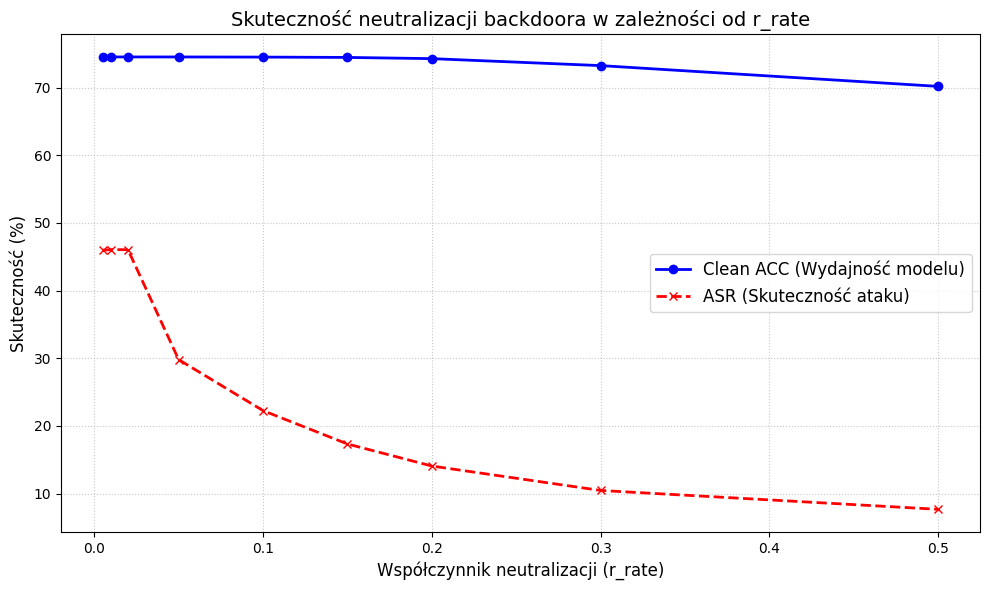

In [26]:
results_dict = find_optimal_r_rate(
    infected_model=model, 
    spurious_dataloader=spurious_dataloader,
    testloader_clean=testloader_clean, 
    testloader_poisoned=testloader_poisoned
)

plot_fcr_results(results_dict)

### Porównanie dla najlepszego

In [31]:
cleansed_resnet = run_fcr_for_backdoor(
    infected_model=model, 
    spurious_dl=spurious_dataloader, 
    r_rate=0.5
)

Rozpoczynamy neutralizację backdoora metodą FCR...
Fine-tuning modelu M' do rozpoznawania fikcyjnej klasy...


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:02<00:00,  2.20it/s]


Obliczanie aktywacji i gradientów...
Aplikowanie zmiany wagi do oryginalnego modelu ze współczynnikiem r=0.5...
Edytowana waga: [neuron wyj:0, neuron wej:348]
Stara wartość: -0.0903, Nowa wartość: 12.5700


In [32]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

In [33]:
print("--- Wyniki przed czyszczeniem ---")
print(f"Clean ACC: {evaluate(model, testloader_clean):.2f}%")
print(f"Attack Success Rate (Poisoned ACC): {evaluate(model, testloader_poisoned):.2f}%")

print("\n--- Wyniki po czyszczeniu (FCR) ---")
print(f"Clean ACC: {evaluate(cleansed_resnet, testloader_clean):.2f}%")
print(f"Attack Success Rate (Poisoned ACC): {evaluate(cleansed_resnet, testloader_poisoned):.2f}%")

--- Wyniki przed czyszczeniem ---
Clean ACC: 74.53%
Attack Success Rate (Poisoned ACC): 46.02%

--- Wyniki po czyszczeniu (FCR) ---
Clean ACC: 70.18%
Attack Success Rate (Poisoned ACC): 7.71%


In [34]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

print("\n--- EWALUACJA MODELU PO ODUCZANIU ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=cleansed_resnet, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 74.53%
Poison Accuracy:                          46.11%
Spurious Correlation Impact (ASR):        68.20%
-> W 4433 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

--- EWALUACJA MODELU PO ODUCZANIU ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 70.18%
Poison Accuracy:                          7.65%
Spurious Correlation Impact (ASR):        0.06%
-> W 4 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


## Patch w stałym miejscu

### Badanie r-rate

--- ETAP 1: Szukanie najważniejszej wagi (wykonywane tylko raz) ---
Trenowanie modelu M' do detekcji backdoora (5 epok)...
Obliczanie metryki SCA-score...

--- ETAP 2: Ewaluacja oryginalnego modelu ---
Stan początkowy -> Clean ACC: 74.13% | ASR (Sukces Ataku): 44.56%

--- ETAP 3: Testowanie różnych wartości r_rate ---
Edytowana waga: [neuron wyj:0, neuron wej:423]
Stara wartość: -0.0405, Nowa wartość: 0.2402
r_rate = 0.005 | Clean ACC: 74.13% | ASR: 44.67%
Edytowana waga: [neuron wyj:0, neuron wej:423]
Stara wartość: -0.0405, Nowa wartość: 0.5210
r_rate = 0.01  | Clean ACC: 74.13% | ASR: 44.84%
Edytowana waga: [neuron wyj:0, neuron wej:423]
Stara wartość: -0.0405, Nowa wartość: 1.0826
r_rate = 0.02  | Clean ACC: 74.13% | ASR: 36.95%
Edytowana waga: [neuron wyj:0, neuron wej:423]
Stara wartość: -0.0405, Nowa wartość: 2.7672
r_rate = 0.05  | Clean ACC: 74.13% | ASR: 22.16%
Edytowana waga: [neuron wyj:0, neuron wej:423]
Stara wartość: -0.0405, Nowa wartość: 5.5750
r_rate = 0.1   | Clean A

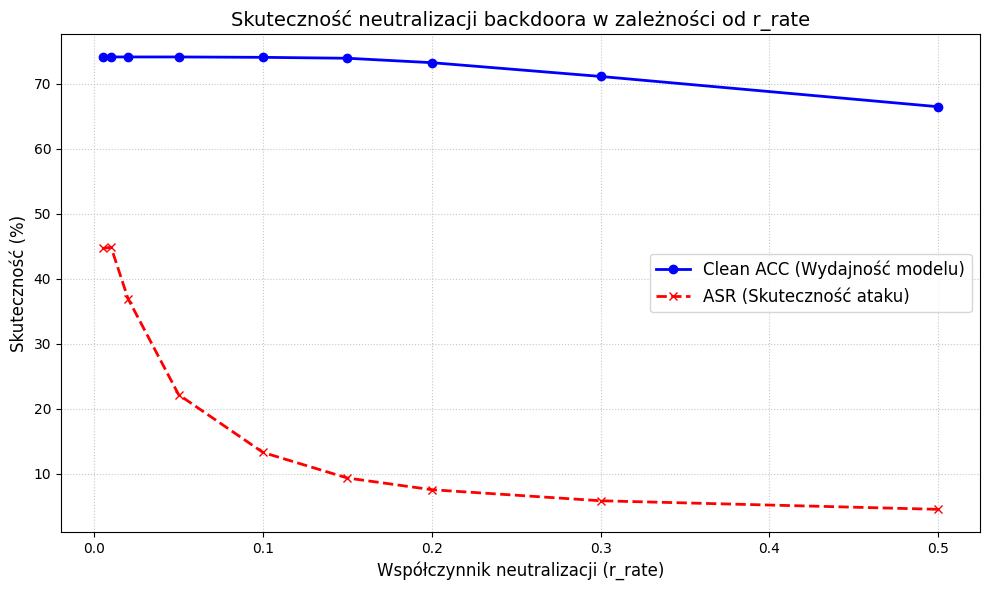

In [38]:
results_dict = find_optimal_r_rate(
    infected_model=model, 
    spurious_dataloader=spurious_dataloader,
    testloader_clean=testloader_clean, 
    testloader_poisoned=testloader_poisoned
)

plot_fcr_results(results_dict)

### Porównanie dla najlepszego

In [39]:
cleansed_resnet = run_fcr_for_backdoor(
    infected_model=model, 
    spurious_dl=spurious_dataloader, 
    r_rate=0.3
)

Rozpoczynamy neutralizację backdoora metodą FCR...
Fine-tuning modelu M' do rozpoznawania fikcyjnej klasy...


100%|██████████| 5/5 [00:02<00:00,  2.19it/s]


Obliczanie aktywacji i gradientów...
Aplikowanie zmiany wagi do oryginalnego modelu ze współczynnikiem r=0.3...
Edytowana waga: [neuron wyj:1, neuron wej:423]
Stara wartość: -0.0690, Nowa wartość: 10.5178


In [40]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

In [41]:
print("--- Wyniki przed czyszczeniem ---")
print(f"Clean ACC: {evaluate(model, testloader_clean):.2f}%")
print(f"Attack Success Rate (Poisoned ACC): {evaluate(model, testloader_poisoned):.2f}%")

print("\n--- Wyniki po czyszczeniu (FCR) ---")
print(f"Clean ACC: {evaluate(cleansed_resnet, testloader_clean):.2f}%")
print(f"Attack Success Rate (Poisoned ACC): {evaluate(cleansed_resnet, testloader_poisoned):.2f}%")

--- Wyniki przed czyszczeniem ---
Clean ACC: 74.13%
Attack Success Rate (Poisoned ACC): 44.56%

--- Wyniki po czyszczeniu (FCR) ---
Clean ACC: 73.46%
Attack Success Rate (Poisoned ACC): 7.82%


In [42]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

print("\n--- EWALUACJA MODELU PO ODUCZANIU ---")
clean_acc_before, asr_before = evaluate_spurious_correlation(
    model=cleansed_resnet, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 74.13%
Poison Accuracy:                          44.56%
Spurious Correlation Impact (ASR):        70.82%
-> W 4603 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

--- EWALUACJA MODELU PO ODUCZANIU ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 73.46%
Poison Accuracy:                          7.82%
Spurious Correlation Impact (ASR):        0.18%
-> W 12 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------
